# Trying to find out what is wrong, Aug. 19, 2026

It seems that the test results of `HRDPS 1km` is wrong. This notebook tries to find out the reasons.


## Find a Grid Point

In [4]:
# find a grid in the north 

import xarray as xr
import numpy as np



path_HRDPS = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d01.nc'
path_HRDPS_1km = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_Conversion/Data_HRDPS_1km_conversion/HRDPS_1km_y2023m03d01.nc'

# read files
ds_HRDPS_1km = xr.open_dataset(path_HRDPS_1km)
ds_HRDPS = xr.open_dataset(path_HRDPS)


def find_nearest_grid_point(ds, target_lon, target_lat, dataset_name):
    """
    找到二维 nav_lon/nav_lat 网格中距离目标经纬度最近的格点。
    返回并打印格点索引 (y, x)、实际经纬度和距离。
    """

    lon = ds['nav_lon'].values
    lat = ds['nav_lat'].values

    # 将目标经度转换到与数据相同的经度范围
    # 数据经度为 [-180, 180] 时，将 305 转换为 -55
    if np.nanmin(lon) < 0:
        target_lon_used = (target_lon + 180) % 360 - 180
    else:
        target_lon_used = target_lon % 360

    # Haversine公式：计算球面距离
    lon_rad = np.deg2rad(lon)
    lat_rad = np.deg2rad(lat)
    target_lon_rad = np.deg2rad(target_lon_used)
    target_lat_rad = np.deg2rad(target_lat)

    delta_lon = lon_rad - target_lon_rad
    delta_lat = lat_rad - target_lat_rad

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(target_lat_rad)
        * np.cos(lat_rad)
        * np.sin(delta_lon / 2) ** 2
    )

    # 防止浮点误差导致 a 略微超过 [0, 1]
    a = np.clip(a, 0, 1)

    earth_radius_km = 6371.0
    distance_km = 2 * earth_radius_km * np.arcsin(np.sqrt(a))

    # 忽略缺失值，寻找最近格点
    flat_index = np.nanargmin(distance_km)
    y_index, x_index = np.unravel_index(flat_index, distance_km.shape)

    print(f'\n{dataset_name}:')
    print(f'  target lon/lat = ({target_lon_used:.6f}, {target_lat:.6f})')
    print(f'  nearest grid index: y = {y_index}, x = {x_index}')
    print(
        f'  nearest grid lon/lat = '
        f'({lon[y_index, x_index]:.6f}, {lat[y_index, x_index]:.6f})'
    )
    print(f'  distance = {distance_km[y_index, x_index]:.3f} km')

    return y_index, x_index


# 目标位置: use sandheads
target_lon = -123.3
target_lat = 49.1

y_HRDPS_1km, x_HRDPS_1km = find_nearest_grid_point(
    ds_HRDPS_1km,
    target_lon,
    target_lat,
    'HRDPS_1km'
)

y_HRDPS, x_HRDPS = find_nearest_grid_point(
    ds_HRDPS,
    target_lon,
    target_lat,
    'HRDPS'
)


HRDPS_1km:
  target lon/lat = (236.700000, 49.100000)
  nearest grid index: y = 221, x = 354
  nearest grid lon/lat = (236.703248, 49.100624)
  distance = 0.246 km

HRDPS:
  target lon/lat = (236.700000, 49.100000)
  nearest grid index: y = 118, x = 108
  nearest grid lon/lat = (236.697576, 49.096376)
  distance = 0.440 km


## Time Series for all variables (the. forcing field was not correctly converted)

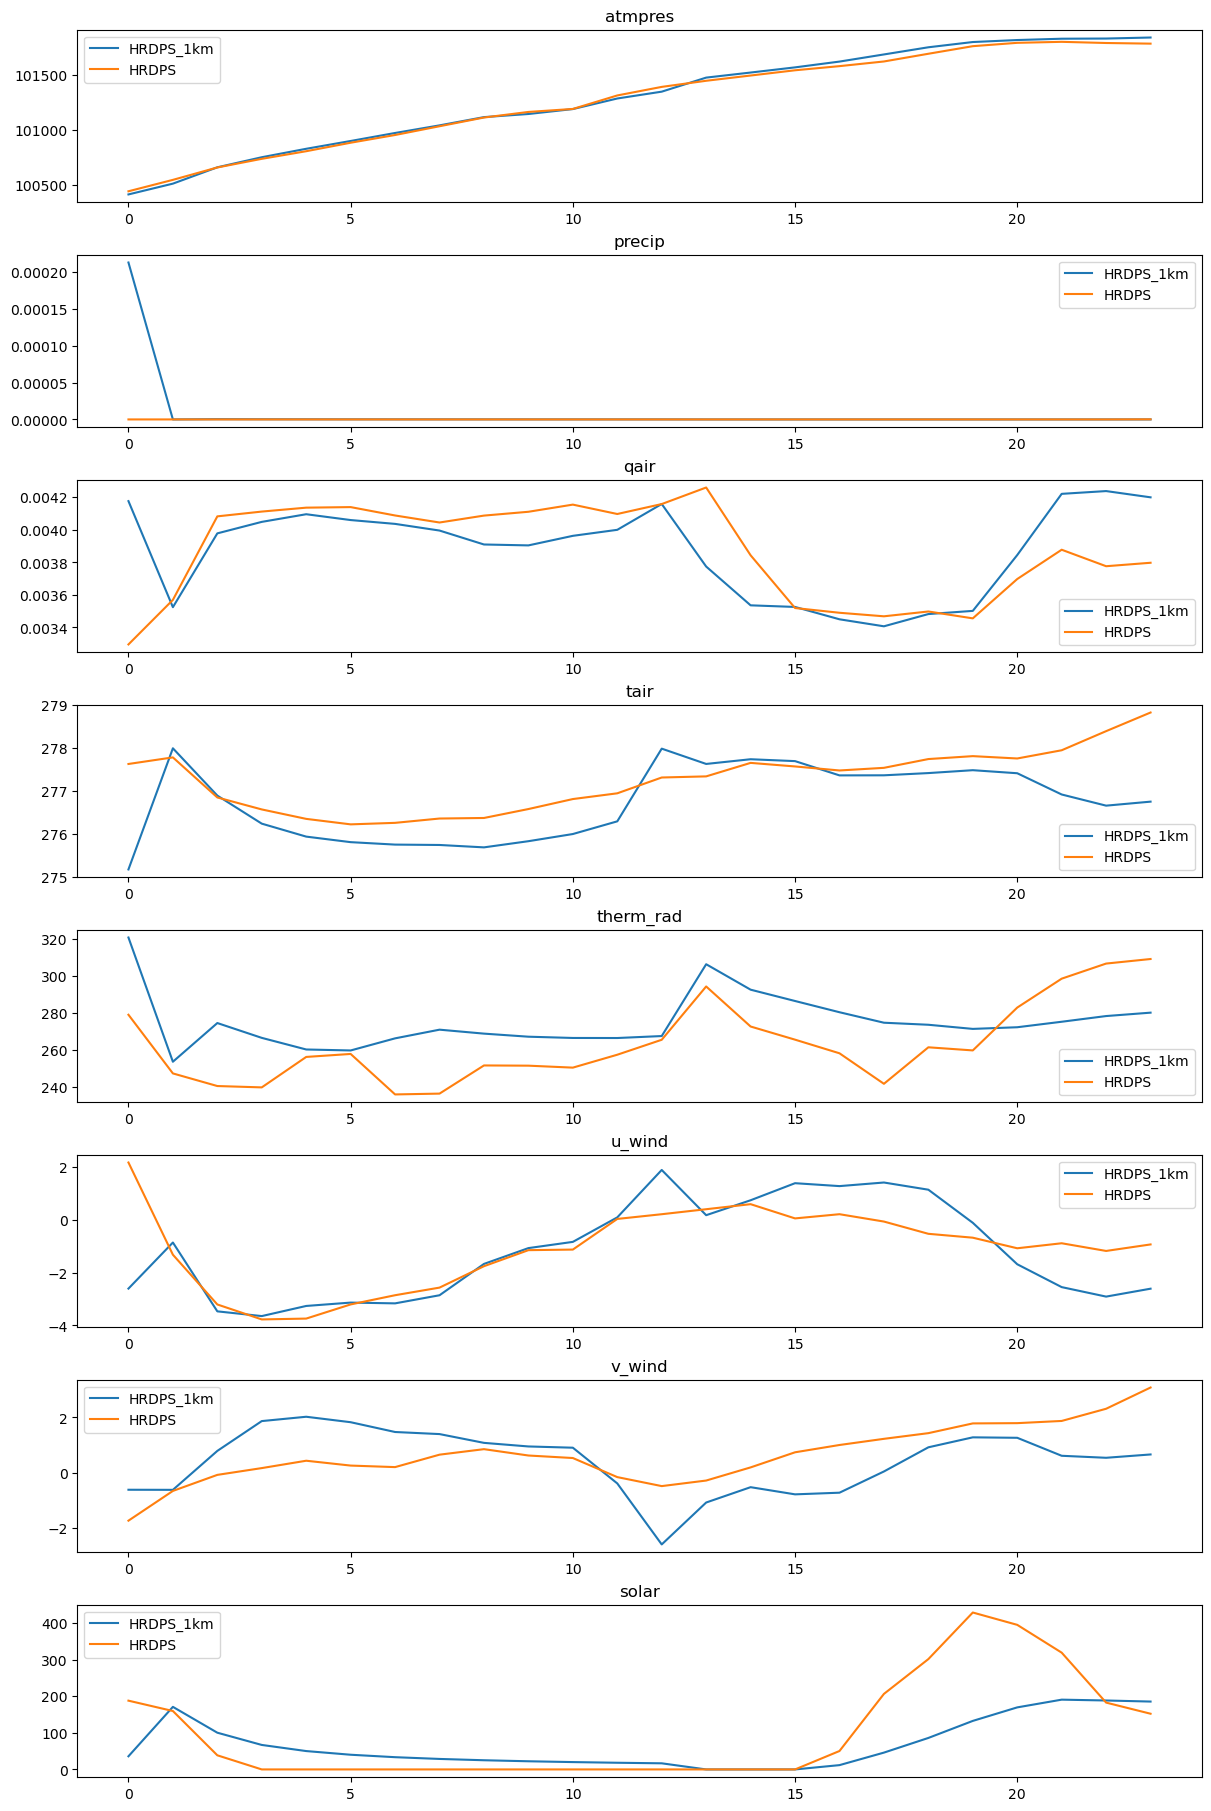

In [6]:
# visualize all kinds of variables to see if there are
# any accumulation/flux mistakes

import xarray as xr
import numpy as np

# Define file paths
path_HRDPS_1km = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_Conversion/Data_HRDPS_1km_conversion/HRDPS_1km_y2023m03d01.nc'
path_HRDPS = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m03d01.nc'

# load data

ds_HRDPS_1km=xr.load_dataset(path_HRDPS_1km)
ds_HRDPS=xr.load_dataset(path_HRDPS)


# grid number
# HRDPS_1km: y = 221, x = 354
# HRDPS: y = 118, x = 108

# list of all variables

list_var=['atmpres', 'precip', 'qair', 'tair', 'therm_rad','u_wind','v_wind','solar']

# visualize

import matplotlib.pyplot as plt

row_number=len(list_var)

fig, axes = plt.subplots(row_number,1,
    figsize=(12, 18),
    constrained_layout=True,
)

# use loop to read the variable

for i in range(row_number):
    var=list_var[i]
    series_HRDPS_1km=ds_HRDPS_1km[var].isel(y=221,x=354).values
    series_HRDPS=ds_HRDPS[var].isel(y=118,x=108).values

    axes[i].plot(series_HRDPS_1km, label='HRDPS_1km')
    axes[i].plot(series_HRDPS, label='HRDPS')
    axes[i].set_title(var)
    axes[i].legend()

## Find the real rotation angle

In [7]:
# find out the exact rotation angle

from pathlib import Path

import numpy as np
import xarray as xr


U_FILE = Path(
    "/results/forcing/atmospheric/GEM1.0/GRIB/"
    "20230301/00/003/"
    "CMC_hrdps_west_UGRD_TGL_10_rotated_latlon0.009x0.009_"
    "20230301T00Z_P003-00.grib2"
)

V_FILE = Path(
    "/results/forcing/atmospheric/GEM1.0/GRIB/"
    "20230301/00/003/"
    "CMC_hrdps_west_VGRD_TGL_10_rotated_latlon0.009x0.009_"
    "20230301T00Z_P003-00.grib2"
)


def open_grib(path):
    ds = xr.open_dataset(
        path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )

    varname = list(ds.data_vars)[0]
    da = ds[varname].squeeze(drop=True).load()

    return ds, da


def bearing_from_point_to_point(lat1, lon1, lat2, lon2):
    """
    返回从点1指向点2的 bearing，
    单位 degree，定义为：
        0   = true north
        90  = true east
        180 = south
        270 = west
    """
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)

    dlon = lon2 - lon1

    y = np.sin(dlon) * np.cos(lat2)

    x = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1)
        * np.cos(lat2)
        * np.cos(dlon)
    )

    bearing = np.rad2deg(np.arctan2(y, x))

    return (bearing + 360.0) % 360.0


ds_u, u = open_grib(U_FILE)
ds_v, v = open_grib(V_FILE)

lat = ds_u["latitude"].values
lon = ds_u["longitude"].values

ny, nx = lat.shape

print("=" * 70)
print("U VARIABLE")
print("=" * 70)
print("name:", u.name)
print("shape:", u.shape)
print()
print("attrs:")
for key, value in sorted(u.attrs.items()):
    if (
        "GRIB" in key
        or "grid" in key.lower()
        or "rotation" in key.lower()
        or "relative" in key.lower()
    ):
        print(f"{key}: {value}")

print()
print("=" * 70)
print("DATASET ATTRIBUTES")
print("=" * 70)

for key, value in sorted(ds_u.attrs.items()):
    print(f"{key}: {value}")


print()
print("=" * 70)
print("GRID")
print("=" * 70)

print("shape:", lat.shape)
print("lat min/max:", np.nanmin(lat), np.nanmax(lat))
print("lon min/max:", np.nanmin(lon), np.nanmax(lon))


# ------------------------------------------------------------
# 取几个代表性的网格点
# ------------------------------------------------------------

points = {
    "center": (ny // 2, nx // 2),
    "SW-ish": (ny // 4, nx // 4),
    "SE-ish": (ny // 4, 3 * nx // 4),
    "NW-ish": (3 * ny // 4, nx // 4),
    "NE-ish": (3 * ny // 4, 3 * nx // 4),
}


print()
print("=" * 70)
print("LOCAL GRID-X ORIENTATION")
print("=" * 70)

for name, (j, i) in points.items():

    # 用 x 方向中心差分：
    # (j, i-1) -> (j, i+1)
    i0 = max(i - 1, 0)
    i1 = min(i + 1, nx - 1)

    bearing_x = bearing_from_point_to_point(
        lat[j, i0],
        lon[j, i0],
        lat[j, i1],
        lon[j, i1],
    )

    # bearing 90° 就是真东。
    # 定义 rotation_from_true_east：
    # 正值 = grid +x 从 true east 朝 true north 偏
    rotation_from_true_east = 90.0 - bearing_x

    # wrap 到 [-180, 180]
    rotation_from_true_east = (
        rotation_from_true_east + 180.0
    ) % 360.0 - 180.0

    print()
    print(name)
    print(f"  index             = ({j}, {i})")
    print(f"  lat/lon           = {lat[j, i]:.8f}, {lon[j, i]:.8f}")
    print(f"  U_grid            = {float(u.values[j, i]):.6f}")
    print(f"  V_grid            = {float(v.values[j, i]):.6f}")
    print(f"  grid-x bearing    = {bearing_x:.8f} deg from true north")
    print(
        "  grid-x vs east    = "
        f"{rotation_from_true_east:.8f} deg"
    )


# ------------------------------------------------------------
# 再检查 grid-y 是否与 grid-x 近似正交
# ------------------------------------------------------------

print()
print("=" * 70)
print("LOCAL GRID-Y ORIENTATION")
print("=" * 70)

for name, (j, i) in points.items():

    j0 = max(j - 1, 0)
    j1 = min(j + 1, ny - 1)

    bearing_y = bearing_from_point_to_point(
        lat[j0, i],
        lon[j0, i],
        lat[j1, i],
        lon[j1, i],
    )

    print()
    print(name)
    print(f"  grid-y bearing    = {bearing_y:.8f} deg from true north")


ds_u.close()
ds_v.close()

U VARIABLE
name: u10
shape: (1180, 1330)

attrs:
GRIB_NV: 0
GRIB_Nx: 1330
GRIB_Ny: 1180
GRIB_angleOfRotationInDegrees: 0.0
GRIB_cfName: eastward_wind
GRIB_cfVarName: u10
GRIB_dataType: af
GRIB_gridDefinitionDescription: Rotated latitude/longitude
GRIB_gridType: rotated_ll
GRIB_iDirectionIncrementInDegrees: 0.00899
GRIB_iScansNegatively: 0
GRIB_jDirectionIncrementInDegrees: 0.00899
GRIB_jPointsAreConsecutive: 0
GRIB_jScansPositively: 1
GRIB_latitudeOfFirstGridPointInDegrees: -5.29511
GRIB_latitudeOfLastGridPointInDegrees: 5.3041
GRIB_latitudeOfSouthernPoleInDegrees: -33.443381
GRIB_longitudeOfFirstGridPointInDegrees: 337.819605
GRIB_longitudeOfLastGridPointInDegrees: 349.767313
GRIB_longitudeOfSouthernPoleInDegrees: 266.463574
GRIB_missingValue: 3.4028234663852886e+38
GRIB_name: 10 metre U wind component
GRIB_numberOfPoints: 1569400
GRIB_paramId: 165
GRIB_shortName: 10u
GRIB_stepType: instant
GRIB_stepUnits: 1
GRIB_typeOfLevel: heightAboveGround
GRIB_units: m s**-1
GRIB_uvRelativeToGrid